# From raw EEG to ERD/ERS spectrogram images

This notebook walks through the signal pipeline of **quiet-cortex** on BCI Competition IV dataset 2a
(Brunner et al., 2008): raw EEG → small Laplacian → Morlet time-frequency power → baseline-normalized
ERD/ERS map → 5-panel spectrogram image. It ends with the grand-average ERD/ERS per motor imagery class,
which is the sanity check for the whole pipeline.

All logic lives in `src/`; this notebook only calls it and visualizes the results.
Time is always expressed relative to the cue (cue = 0 s, imagery 0–4 s).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

from src.data import (crop_times, erd_path, extract_epochs, find_trials, freqs_from_cfg, laplacian,
                      load_classlabel, load_raw, percent_change, plot_grand_average, render_erd, smooth,
                      tfr_power)
from src.utils.coords import F_MAX, F_MIN, MI_CLASSES, PANEL_H, PANEL_ORDER, T_MAX, T_MIN
from src.utils.io import load_config, resolve

cfg = load_config("configs/preprocess.yaml")
meta = pd.read_csv(resolve(cfg["paths"]["processed_dir"]) / "metadata.csv", keep_default_na=False)
SUBJECT = "A03"  # example subject for the single-trial figures

## 1. Trials, labels, and rejected trials

Trials are located by their cue events (769–772 in session T, 783 in session E). Session E labels come from
the official true-label files. A trial is dropped if an artifact marker (1023) belongs to it.

In [2]:
counts = (meta.groupby(["subject", "session"])
          .agg(cues=("trial_idx", "size"), rejected=("rejected", "sum"))
          .assign(kept=lambda d: d.cues - d.rejected)
          .unstack("session"))
counts

cues      rejected     kept     
session    E    T        E   T    E    T
subject                                 
A01      288  288        7  15  281  273
A02      288  288        5  18  283  270
A03      288  288       15  18  273  270
A04      288  288       60  26  228  262
A05      288  288       12  26  276  262
A06      288  288       73  69  215  219
A07      288  288       11  17  277  271
A08      288  288       17  24  271  264
A09      288  288       24  51  264  237

In [3]:
kept = meta[~meta.rejected]
print("kept trials per session:", kept.groupby("session").size().to_dict())
kept.groupby(["session", "class_name"]).size().unstack()

kept trials per session: {'E': 2368, 'T': 2328}


class_name,feet,left_hand,right_hand,tongue
session,,,,
E,600,593,590,585
T,574,572,591,591


## 2. Raw signal around one trial

The signal is band-pass filtered (4–40 Hz, zero-phase FIR) on the continuous recording, then cut into
epochs from −1.5 s to +5.75 s around the cue. The extra margins absorb wavelet edge effects and are
cropped away after the time-frequency transform. The small Laplacian subtracts the mean of the
neighboring electrodes, which sharpens the spatial focus on each target channel.

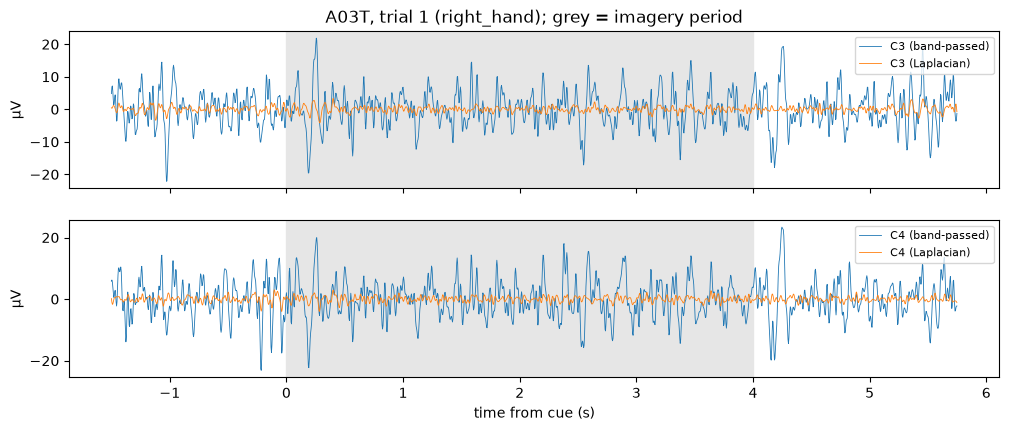

In [4]:
raw = load_raw(resolve(cfg["paths"]["gdf_dir"]) / f"{SUBJECT}T.gdf", cfg["sfreq"])
trials = find_trials(raw, "T", load_classlabel(resolve(cfg["paths"]["labels_dir"]), f"{SUBJECT}T"),
                     tuple(cfg["rejection_window_s"]))
raw.filter(cfg["bandpass"]["l_freq"], cfg["bandpass"]["h_freq"], fir_design="firwin", verbose="ERROR")
ok = trials[~trials.rejected].reset_index(drop=True)
epochs = extract_epochs(raw.get_data(), cfg["sfreq"], ok.cue_onset_s.to_numpy(),
                        cfg["epoch"]["tmin"], cfg["epoch"]["tmax"])
lap = laplacian(epochs, raw.ch_names, cfg["laplacian"])
y = ok.class_id.to_numpy()

i = int(np.flatnonzero(y == 1)[0])  # first right-hand trial
t_ep = cfg["epoch"]["tmin"] + np.arange(epochs.shape[-1]) / cfg["sfreq"]
fig, axes = plt.subplots(2, 1, figsize=(12, 4.5), sharex=True)
for ax, ch in zip(axes, ["C3", "C4"]):
    ax.plot(t_ep, epochs[i, raw.ch_names.index(ch)] * 1e6, lw=0.6, label=f"{ch} (band-passed)")
    ax.plot(t_ep, lap[i, PANEL_ORDER.index(ch)] * 1e6, lw=0.6, label=f"{ch} (Laplacian)")
    ax.axvspan(0, 4, color="0.9", zorder=0)
    ax.set_ylabel("µV")
    ax.legend(loc="upper right", fontsize=8)
axes[0].set_title(f"{SUBJECT}T, trial {ok.trial_idx[i]} ({MI_CLASSES[y[i]]}); grey = imagery period")
axes[-1].set_xlabel("time from cue (s)")
plt.show()

## 3. Time-frequency map and why it is smoothed

Morlet power (4–40 Hz, 1 Hz steps, `n_cycles = f / 2`) is cropped to −1.0 … 5.5 s and expressed as percent
change from the mean power in the −1.0 … 0 s baseline of the same trial:

`ERD/ERS (%) = (P(t, f) − P_baseline(f)) / P_baseline(f) × 100`

Single-trial power fluctuates strongly: the band power of a noisy rhythm is roughly exponentially
distributed, so values 20 % below the mean occur very often even when nothing happens. The auto-labeling
threshold is fixed at ±20 % (`configs/autolabel.yaml`), so the map is smoothed with a Gaussian before
thresholding and rendering. The panels below compare no smoothing, a light smoothing (σ = 1 Hz × 50 ms),
and the smoothing used in this project (σ = 2 Hz × 0.4 s) for channel C3 of the same right-hand trial.

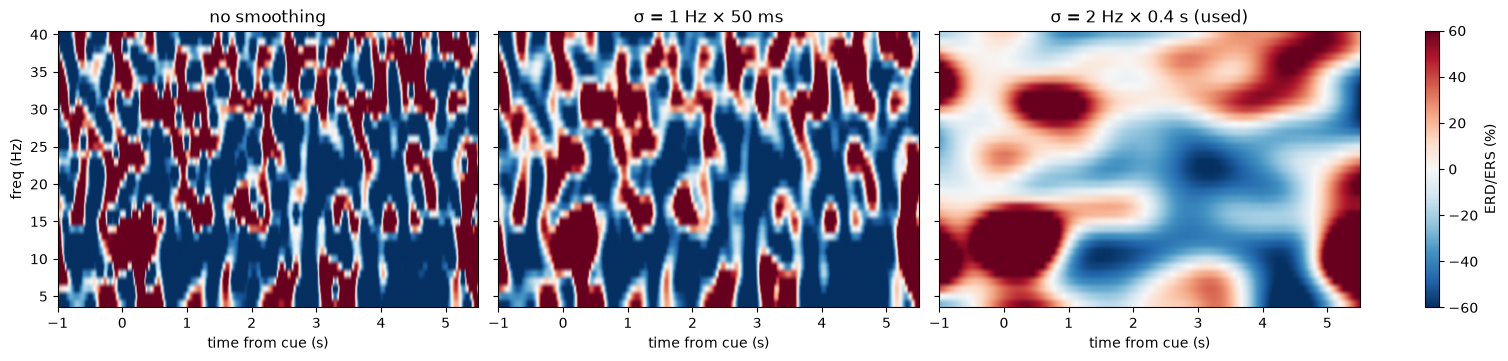

In [5]:
power = tfr_power(lap, cfg)
pct = percent_change(power, cfg)
light = dict(cfg, smoothing={"sigma_hz": 1.0, "sigma_s": 0.05})
variants = {"no smoothing": pct[i], "σ = 1 Hz × 50 ms": smooth(pct[i], light),
            "σ = 2 Hz × 0.4 s (used)": smooth(pct[i], cfg)}

p = PANEL_ORDER.index("C3")
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5), sharey=True, constrained_layout=True)
for ax, (name, m) in zip(axes, variants.items()):
    im = ax.imshow(m[p], origin="lower", aspect="auto", cmap="RdBu_r", vmin=-60, vmax=60,
                   extent=[T_MIN, T_MAX, F_MIN - 0.5, F_MAX + 0.5])
    ax.set_title(name)
    ax.set_xlabel("time from cue (s)")
axes[0].set_ylabel("freq (Hz)")
fig.colorbar(im, ax=axes, label="ERD/ERS (%)")
plt.show()

How often does the ERD threshold (≤ −20 % in 8–30 Hz) fire **before the cue**, where no task-related ERD
exists, compared with the imagery window (0.5–4 s) on the expected channel? Computed for the example
subject only.

In [6]:
t = crop_times(cfg)
f = freqs_from_cfg(cfg)
band = (f >= 8) & (f <= 30)
base_t, imag_t = (t >= -1) & (t <= 0), (t >= 0.5) & (t <= 4)
rows = []
for name, sm in {"σ = 1 Hz × 50 ms": light, "σ = 2 Hz × 0.4 s (used)": cfg}.items():
    E = smooth(pct, sm)[:, :, band]
    rows.append({
        "smoothing": name,
        "baseline, all panels": (E[..., base_t] <= -20).mean(),
        "left hand @ C4, 0.5-4 s": (E[y == 0, PANEL_ORDER.index("C4")][..., imag_t] <= -20).mean(),
        "right hand @ C3, 0.5-4 s": (E[y == 1, PANEL_ORDER.index("C3")][..., imag_t] <= -20).mean(),
    })
print("Fraction of 8-30 Hz pixels <= -20 %")
pd.DataFrame(rows).set_index("smoothing").round(3)

Fraction of 8-30 Hz pixels <= -20 %


,"baseline, all panels","left hand @ C4, 0.5-4 s","right hand @ C3, 0.5-4 s"
smoothing,,,
σ = 1 Hz × 50 ms,0.451,0.630,0.757
σ = 2 Hz × 0.4 s (used),0.115,0.513,0.725


## 4. Rendered 5-panel image

One trial becomes one 640 × 640 image: five 640 × 128 panels stacked top to bottom (C5, C3, Cz, C4, C6,
i.e. left to right hemisphere). Within a panel, frequency runs from 40 Hz (top) to 4 Hz (bottom); x is time
from −1.0 to 5.5 s. Colors use `RdBu_r` with a fixed −60 … +60 % range (blue = ERD, red = ERS). The image
itself contains data pixels only; panel names, separators, and the cue/end-of-imagery lines are added
below for reading.

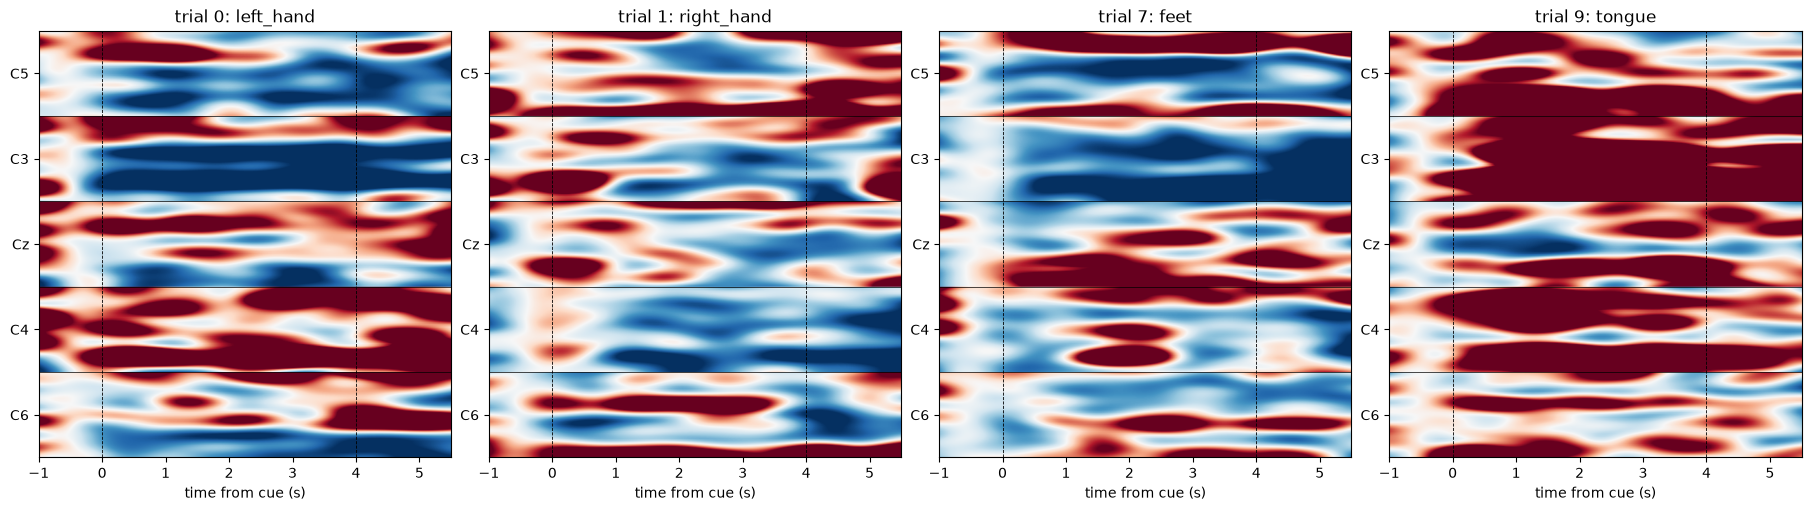

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5), constrained_layout=True)
for ax, c in zip(axes, range(4)):
    r = ok.iloc[int(np.flatnonzero(y == c)[0])]
    img = render_erd(np.load(erd_path(cfg, SUBJECT, "T", int(r.trial_idx))), cfg)
    ax.imshow(img, extent=[T_MIN, T_MAX, 640, 0], aspect="auto")
    ax.set_yticks([(k + 0.5) * PANEL_H for k in range(5)], PANEL_ORDER)
    for k in range(1, 5):
        ax.axhline(k * PANEL_H, color="k", lw=0.5)
    for tv in (0, 4):
        ax.axvline(tv, color="k", ls="--", lw=0.6)
    ax.set_title(f"trial {r.trial_idx}: {r.class_name}")
    ax.set_xlabel("time from cue (s)")
plt.show()

## 5. Grand-average ERD/ERS per class (checkpoint)

The grand average follows the classical ERD definition (Pfurtscheller & Lopes da Silva, 1999): power is
averaged over all trials of a class for each subject, converted to percent change versus the baseline,
and then averaged over the 9 subjects (session T). Expected pattern: mu/beta ERD over the contralateral
hand area (C4 for left hand, C3 for right hand), over Cz for feet, and a beta rebound (ERS) after the
imagery ends at 4 s.

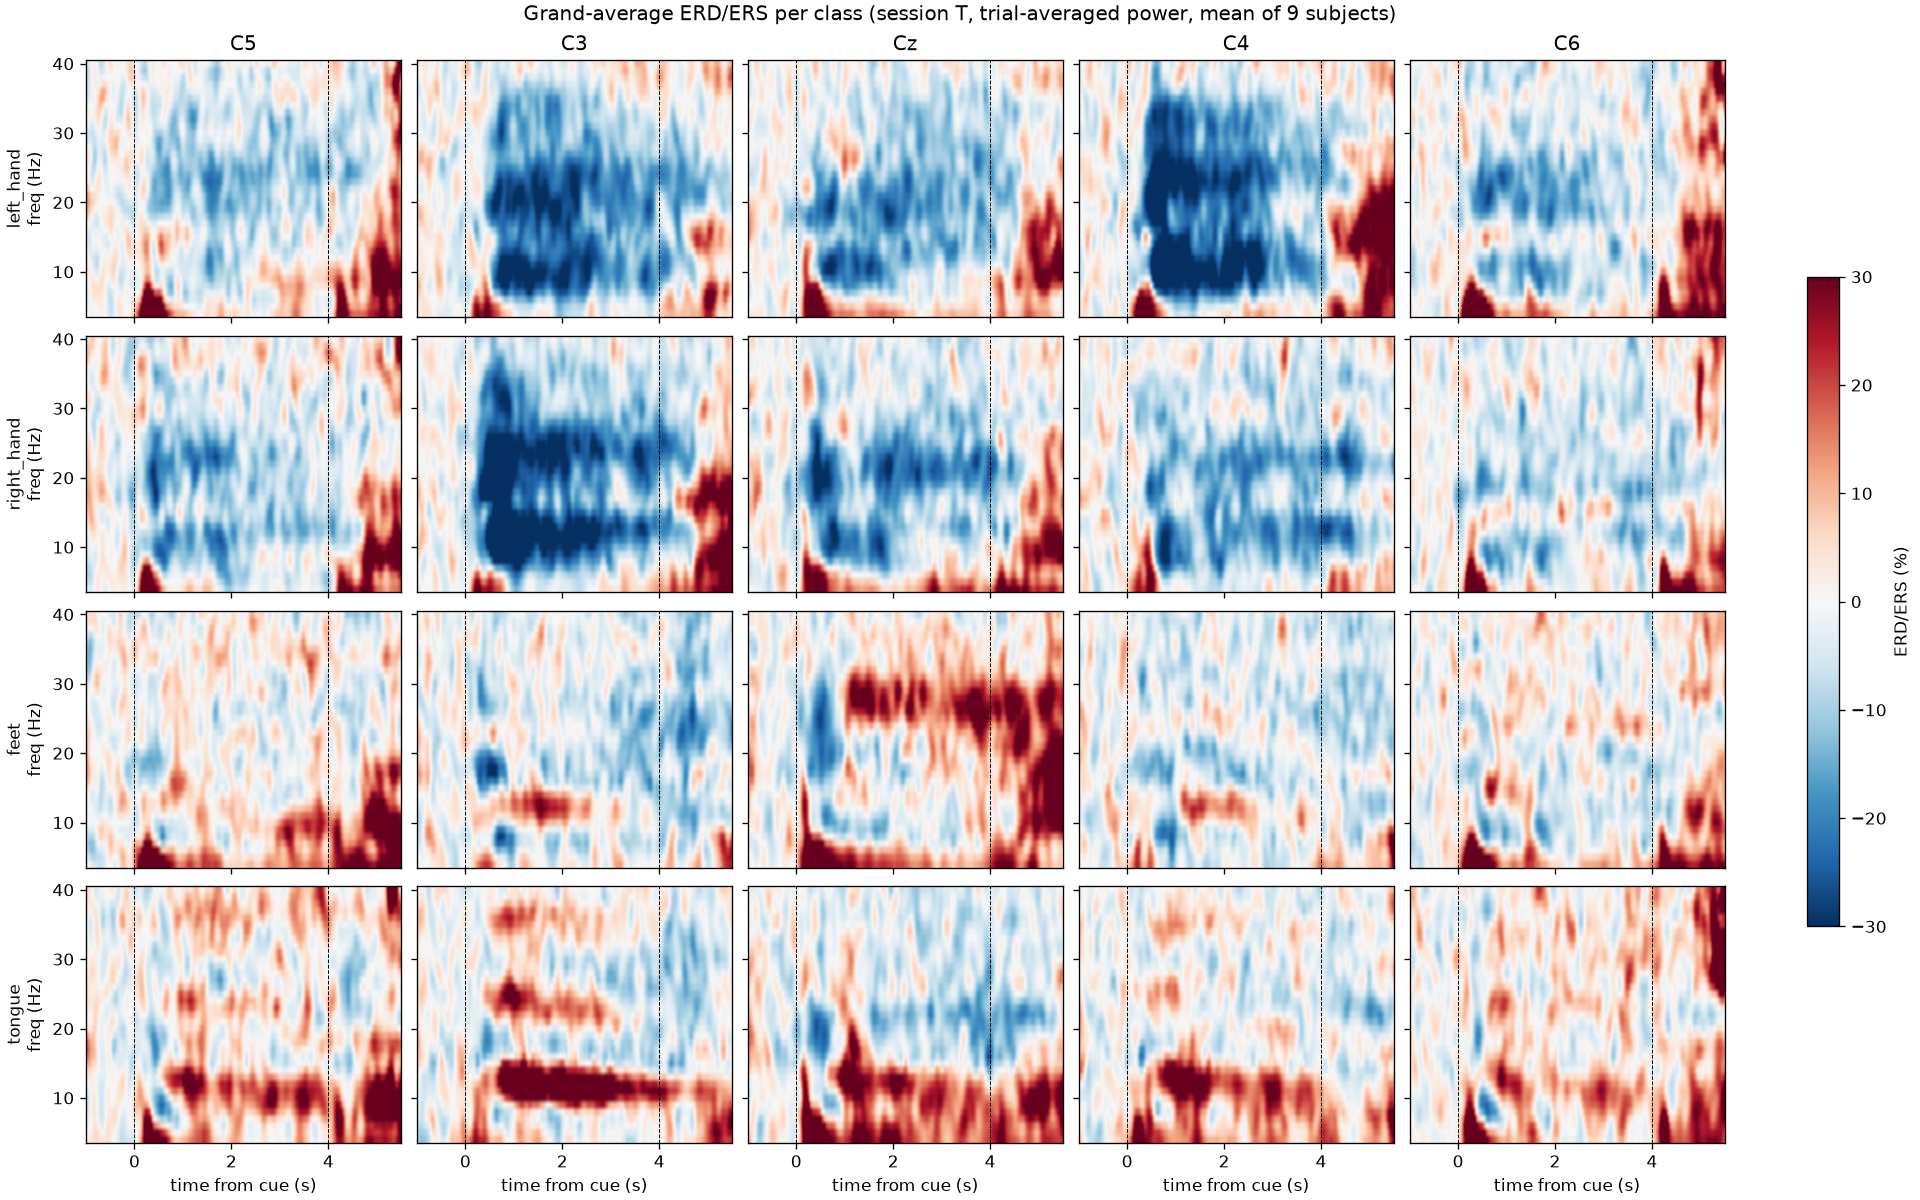

In [8]:
ga = np.load(resolve(cfg["paths"]["processed_dir"]) / "grand_average" / "grand_average_T.npy").astype(np.float64)
plot_grand_average(ga, resolve("results/figures/grand_average_erd.png"))
display(Image(filename=str(resolve("results/figures/grand_average_erd.png"))))

In [9]:
win, rebound = (t >= 0.5) & (t <= 4), (t >= 4) & (t <= 5.5)
beta = (f >= 13) & (f <= 30)
erd = pd.DataFrame(ga[:, :, band][..., win].mean(axis=(2, 3)), index=MI_CLASSES, columns=PANEL_ORDER)
ers = pd.DataFrame(ga[:, :, beta][..., rebound].mean(axis=(2, 3)), index=MI_CLASSES, columns=PANEL_ORDER)
print("Mean ERD/ERS (%) in 8-30 Hz, 0.5-4.0 s (negative = ERD)")
display(erd.round(1))
print("Mean ERD/ERS (%) in 13-30 Hz, 4.0-5.5 s (positive = rebound)")
display(ers.round(1))

Mean ERD/ERS (%) in 8-30 Hz, 0.5-4.0 s (negative = ERD)


,C5,C3,Cz,C4,C6
left_hand,-6.7,-20.1,-12.6,-22.6,-8.4
right_hand,-9.1,-23.8,-12.6,-12.5,-5.8
feet,2.1,-2.7,4.7,-2.1,-0.7
tongue,6.1,9.4,2.1,5.7,5.0


Mean ERD/ERS (%) in 13-30 Hz, 4.0-5.5 s (positive = rebound)


,C5,C3,Cz,C4,C6
left_hand,1.8,-5.7,1.9,11.7,8.2
right_hand,2.0,3.6,1.2,-7.7,-2.3
feet,3.1,-8.1,23.1,-5.8,1.3
tongue,2.2,-4.6,-3.8,-3.3,5.6
